## 3D Resolution Estimation: FSC and DCR on Pollen Confocal Data

This notebook demonstrates directional (XY and Z) resolution estimation on a 3D confocal microscopy
image of pollen using two complementary methods:

- **SFSC** (Sectored Fourier Shell Correlation) — correlation-based, requires image splitting
- **DCR** (Decorrelation Analysis) — single-image, parameter-free

We compare results against the reference values from Koho et al. (2019) Figure 4b:
XY = 0.59 µm, Z = 3.91 µm.

**References:**
- Koho et al. (2019) "Fourier ring correlation simplifies image restoration in fluorescence microscopy", *Nature Communications* 10:3103.
- Descloux et al. (2019) "Parameter-free image resolution estimation based on decorrelation analysis", *Nature Methods* 16:918-924.

In [1]:
import os
import sys

# Ensure CUDA_PATH is set for CuPy JIT compilation
if "CUDA_PATH" not in os.environ:
    os.environ["CUDA_PATH"] = "/hpc/apps/cuda/12.6.3_560.35.05"

sys.path.insert(0, "..")

import nd2
import numpy as np
import matplotlib.pyplot as plt
from plot_utils import plot_dcr_sectors, plot_fsc_sectors

from cubic.cuda import ascupy, asnumpy, get_device
from cubic.image_utils import rescale_isotropic
from cubic.metrics.frc import dcr_resolution, fsc_resolution
from cubic.metrics.frc.dcr import dcr_curve_3d_sectioned
from cubic.metrics.frc.frc import preprocess_images, _calculate_fsc_sectioned_hist

### Load the pollen confocal image

40x confocal image of pollen grain acquired with a Nikon microscope.
Voxel spacing: Z = 0.250 µm, Y = X = 0.0777 µm (anisotropy factor z = 3.22).

In [2]:
spacing = [0.250, 0.0777, 0.0777]  # Z, Y, X in µm

with nd2.ND2File("../data/40x_TAGoff_z_galvo.nd2") as f:
    image = f.asarray()
    print(f"ND2 dimensions: {f.sizes}, dtype: {image.dtype}")
    dim_order = list(f.sizes.keys())
    c_axis = dim_order.index("C")
    image = np.take(image, 0, axis=c_axis).astype(np.float32)

print(f"Image shape (Z, Y, X): {image.shape}")
print(f"Spacing (Z, Y, X): {spacing} µm")
print(f"Anisotropy factor: {spacing[0] / spacing[1]:.2f}")

ND2 dimensions: {'Z': 181, 'C': 2, 'Y': 512, 'X': 512}, dtype: uint16
Image shape (Z, Y, X): (181, 512, 512)
Spacing (Z, Y, X): [0.25, 0.0777, 0.0777] µm
Anisotropy factor: 3.22


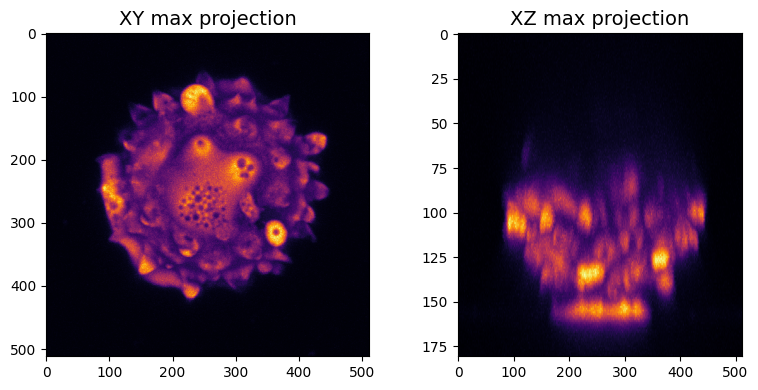

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image.max(0), cmap="inferno")
axes[0].set_title("XY max projection", fontsize=14)
axes[1].imshow(image.max(1), cmap="inferno", aspect=spacing[0] / spacing[1])
axes[1].set_title("XZ max projection", fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
image_gpu = ascupy(image)
print(f"Device: {get_device(image_gpu)}")

Device: GPU


### 3D FSC (Sectored Fourier Shell Correlation)

FSC compares two half-images obtained by checkerboard splitting. In single-image mode,
both forward and reverse splits are averaged to reduce variance (Koho et al. 2019).

Key parameters:
- `resample_isotropic=True`: Upsample Z to isotropic voxels before FSC
- `angle_delta=15`: 15° angular sectors matching the paper
- `resolution_threshold="one-bit"`: SNR-dependent threshold (paper methodology)

In [5]:
fsc_result = fsc_resolution(
    image_gpu,
    spacing=spacing,
    resample_isotropic=True,
    resample_order=1,
    angle_delta=15,
    bin_delta=1,
    resolution_threshold="one-bit",
    backend="hist",
)

print(f"FSC (one-bit threshold):")
print(f"  XY resolution: {fsc_result['xy']:.4f} µm")
print(f"  Z  resolution: {fsc_result['z']:.4f} µm")
print(f"  Z/XY ratio:    {fsc_result['z'] / fsc_result['xy']:.1f}")

FSC (one-bit threshold):
  XY resolution: 0.5819 µm
  Z  resolution: 4.9898 µm
  Z/XY ratio:    8.6


#### FSC correlation curves by angular sector

Each sector captures frequencies at a different polar angle from the Z axis.
The XY sector (θ ≈ 82°) measures lateral resolution; the Z sector (θ ≈ 8°) measures axial resolution.
Resolution is where the FSC curve crosses the one-bit threshold.

In [6]:
# Replicate the preprocessing that fsc_resolution does internally
iso_spacing = spacing[1]  # Y spacing
target_z_size = int(round(image_gpu.shape[0] * spacing[0] / iso_spacing))
if target_z_size % 2 != 0:
    target_z_size -= 1

image_iso = rescale_isotropic(
    image_gpu,
    spacing,
    downscale_xy=False,
    order=1,
    preserve_range=True,
    target_z_size=target_z_size,
).astype(np.float32)

even_shape = tuple(s - (s % 2) for s in image_iso.shape)
if image_iso.shape != even_shape:
    image_iso = image_iso[tuple(slice(0, es) for es in even_shape)]

print(f"Isotropic shape: {image_iso.shape}, spacing: {iso_spacing} µm")

# Checkerboard split + Hamming window
image1, image2 = preprocess_images(
    image_iso,
    None,
    zero_padding=False,
    disable_hamming=False,
    disable_3d_sum=False,
)

# Compute per-sector FSC data
fsc_data = _calculate_fsc_sectioned_hist(
    image1,
    image2,
    bin_delta=1,
    angle_delta=15,
    spacing=[iso_spacing] * 3,
)

print(f"Sectors: {sorted(fsc_data.keys())}")

Isotropic shape: (582, 512, 512), spacing: 0.0777 µm
Sectors: [8, 22, 38, 52, 68, 82]


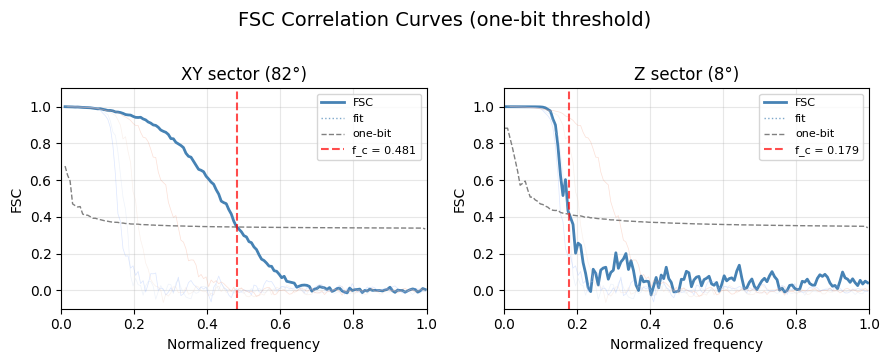

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
plot_fsc_sectors(fsc_data, iso_spacing, threshold="one-bit", axes=axes)
fig.suptitle("FSC Correlation Curves (one-bit threshold)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3D DCR (Decorrelation Analysis)

DCR estimates resolution from a single image by finding the highest frequency with
reproducible phase information. It uses angular sectoring to provide separate XY and Z
estimates, similar to FSC (Descloux et al. 2019).

Unlike FSC, DCR does not require isotropic resampling — it operates directly on the
anisotropic volume with physical spacing.

In [8]:
dcr_result = dcr_resolution(
    image_gpu,
    spacing=spacing,
    use_sectioned=True,
)

print(f"DCR (sectored 3D):")
print(f"  XY resolution: {dcr_result['xy']:.4f} µm")
print(f"  Z  resolution: {dcr_result['z']:.4f} µm")
print(f"  Z/XY ratio:    {dcr_result['z'] / dcr_result['xy']:.1f}")

DCR (sectored 3D):
  XY resolution: 1.0256 µm
  Z  resolution: 2.6197 µm
  Z/XY ratio:    2.6


#### DCR decorrelation curves by angular sector

Each curve corresponds to a different high-pass filter level (increasing sigma).
The resolution is determined by the highest-frequency peak across all curves.

In [9]:
# Compute sectored DCR curves using the library function
dcr_sector_data = dcr_curve_3d_sectioned(
    image_gpu,
    spacing=spacing,
    num_radii=100,
    num_highpass=10,
)

for sector in ["xy", "z"]:
    sd = dcr_sector_data[sector]
    print(
        f"{sector.upper()}: {len(sd['curves'])} curves, "
        f"k_max = {sd['k_max']:.4f} µm⁻¹, "
        f"resolution = {sd['resolution']:.4f} µm"
    )

XY: 21 curves, k_max = 6.4350 µm⁻¹, resolution = 1.0256 µm
Z: 21 curves, k_max = 1.9890 µm⁻¹, resolution = 2.6197 µm


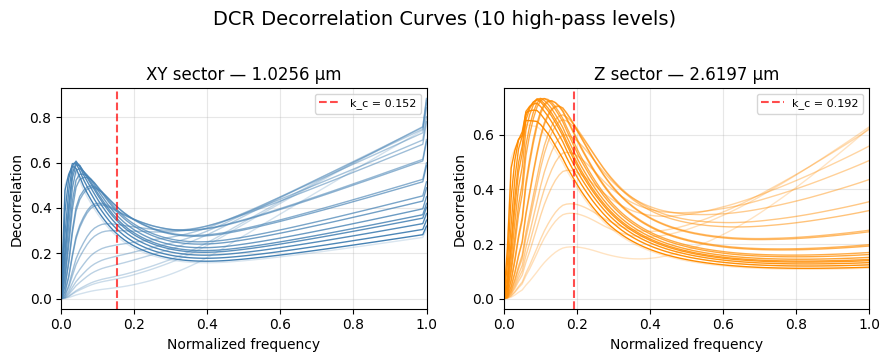

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
plot_dcr_sectors(dcr_sector_data, axes=axes)
fig.suptitle("DCR Decorrelation Curves (10 high-pass levels)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Comparison

Compare all estimates against the Koho et al. 2019 reference values for this pollen image.

In [11]:
paper_xy, paper_z = 0.59, 3.91

methods = {
    "Koho et al.": {"xy": paper_xy, "z": paper_z},
    "FSC one-bit": fsc_result,
    "DCR": dcr_result,
}

print(f"{'Method':<22} {'XY (µm)':<12} {'Z (µm)':<12} {'Z/XY':<8}")
print("-" * 54)
for name, res in methods.items():
    xy, z = res["xy"], res["z"]
    ratio = z / xy if xy > 0 else float("nan")
    print(f"{name:<22} {xy:<12.4f} {z:<12.4f} {ratio:<8.1f}")

Method                 XY (µm)      Z (µm)       Z/XY    
------------------------------------------------------
Koho et al.            0.5900       3.9100       6.6     
FSC one-bit            0.5819       4.9898       8.6     
DCR                    1.0256       2.6197       2.6     
